In [49]:
# Ignore future warnings to keep the notebook clean
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

import osmnx as ox
import networkx as nx
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import spaghetti
import esda
import libpysal
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d
import random

# Set up OSMnx parameters
ox.settings.log_console = True
ox.settings.use_cache = True

# Task A: Extract driving network for Leeds city centre (500m radius)
leeds_center = (53.7997, -1.5492)
radius_meters = 500  

print(f"Extracting network around {leeds_center}...")
G_leeds_raw = ox.graph_from_point(leeds_center, dist=radius_meters, network_type='drive')
print(f"Nodes: {G_leeds_raw.number_of_nodes()}, Edges: {G_leeds_raw.number_of_edges()}")

# Calculate basic spatial metrics
G_leeds_proj = ox.project_graph(G_leeds_raw)
stats = ox.basic_stats(G_leeds_proj)

print("\n Task A: Spatial Metrics ")
print(f"Average street length: {stats.get('street_length_avg', 0):.2f} meters")
print(f"Intersection density: {stats.get('intersection_density_km', 0):.2f} per sq km")
print(f"Edge density: {stats.get('edge_density_km', 0):.2f} meters per sq km")
print(f"Average Circuitry: {stats.get('circuity_avg', 0):.4f}")

# Check network planarity
G_undirected = nx.Graph(G_leeds_raw)
is_planar, embedding = nx.check_planarity(G_undirected)
print(f"Is the network strictly planar? {is_planar}")

Extracting network around (53.7997, -1.5492)...
Nodes: 122, Edges: 211

 Task A: Spatial Metrics 
Average street length: 68.86 meters
Intersection density: 0.00 per sq km
Edge density: 0.00 meters per sq km
Average Circuitry: 1.1237
Is the network strictly planar? True


Valid accidents within the area: 303


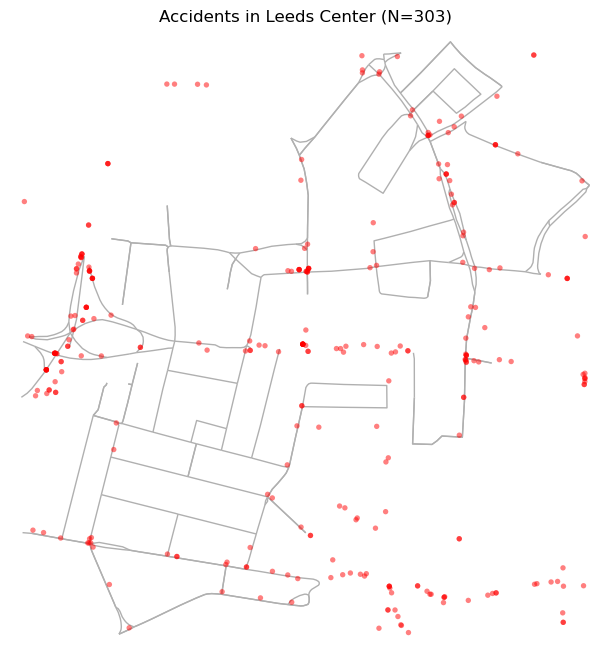

In [50]:
# Task B.1: Map historical traffic accidents
my_files = [
    "Road traffic accidents_2016.csv",
    "Road traffic accidents_2015.csv",
    "Road traffic accidents_2014.csv",
    "Road traffic accidents_2013.csv"
]

df_list = []
for file in my_files:
    try:
        # Use latin1 encoding for older UK datasets
        temp_df = pd.read_csv(file, encoding='latin1')
        df_list.append(temp_df)
    except FileNotFoundError:
        print(f"Cannot find {file}")

df = pd.concat(df_list, ignore_index=True)

# Clean missing coordinates
easting_col = 'Grid Ref: Easting'
northing_col = 'Grid Ref: Northing'
df = df.dropna(subset=[easting_col, northing_col])
df[easting_col] = pd.to_numeric(df[easting_col], errors='coerce')
df[northing_col] = pd.to_numeric(df[northing_col], errors='coerce')
df = df.dropna(subset=[easting_col, northing_col])

# Convert BNG (EPSG:27700) to WGS84 (EPSG:4326)
geometry = [Point(xy) for xy in zip(df[easting_col], df[northing_col])]
gdf_accidents = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:27700")
gdf_accidents = gdf_accidents.to_crs("EPSG:4326")

gdf_accidents['Longitude'] = gdf_accidents.geometry.x
gdf_accidents['Latitude'] = gdf_accidents.geometry.y

# Filter points to fit within our network bounding box
nodes_df = ox.graph_to_gdfs(G_leeds_raw, edges=False)
min_lon, min_lat, max_lon, max_lat = nodes_df.total_bounds

final_accidents_df = gdf_accidents[
    (gdf_accidents['Longitude'] >= min_lon) & (gdf_accidents['Longitude'] <= max_lon) &
    (gdf_accidents['Latitude'] >= min_lat) & (gdf_accidents['Latitude'] <= max_lat)
]

print(f"Valid accidents within the area: {len(final_accidents_df)}")

# Plot raw accidents
fig, ax = ox.plot_graph(
    G_leeds_raw, show=False, close=False, edge_color="#B0B0B0", 
    edge_linewidth=1, node_size=0, bgcolor="white"
)
ax.scatter(final_accidents_df['Longitude'], final_accidents_df['Latitude'], 
           c='red', s=15, alpha=0.5, zorder=5, edgecolors='none')
plt.title(f"Accidents in Leeds Center (N={len(final_accidents_df)})")
plt.show()


 Visualizing snapped accident locations on the Leeds network 


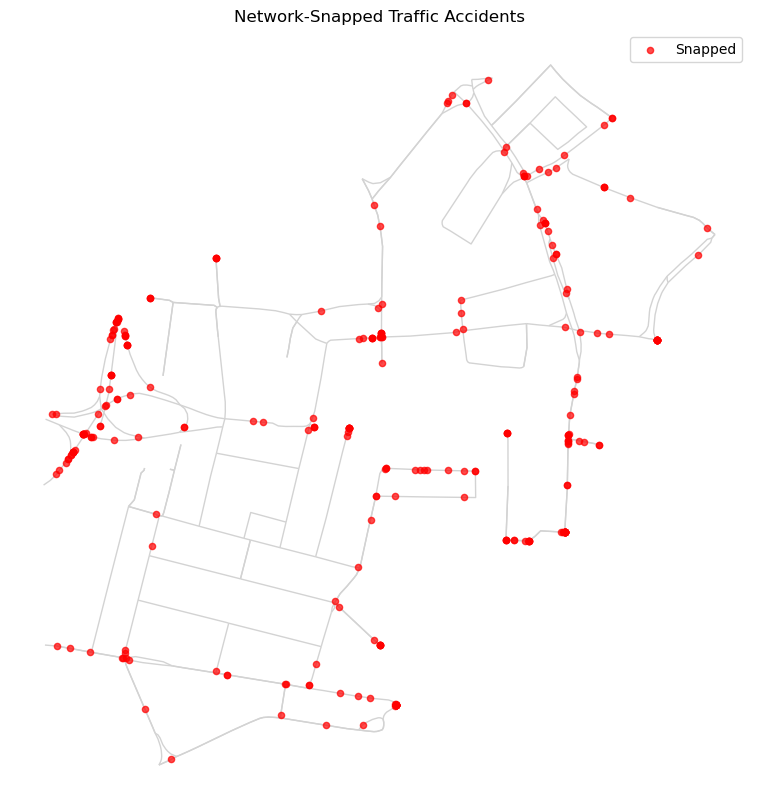


 Network Moran's I results 
Moran's I: 0.0923, P-value: 0.0180

 Task B.2: Network K-Function Plot 
Calculating Network K-Function...


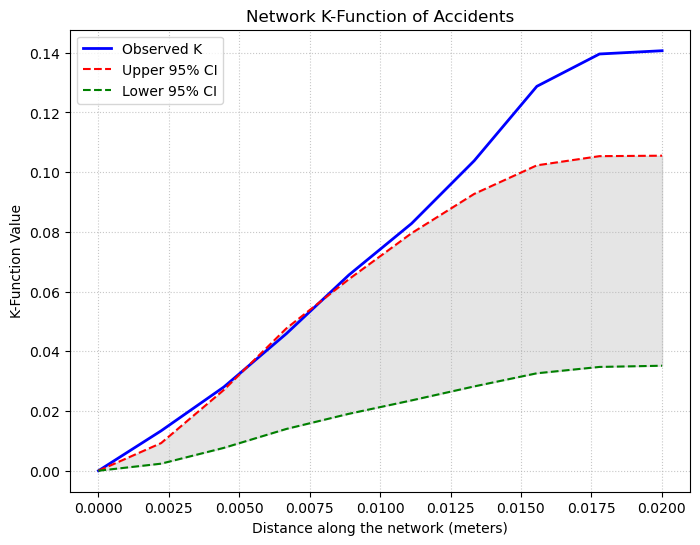


 Task B.3: Proximity Histogram 


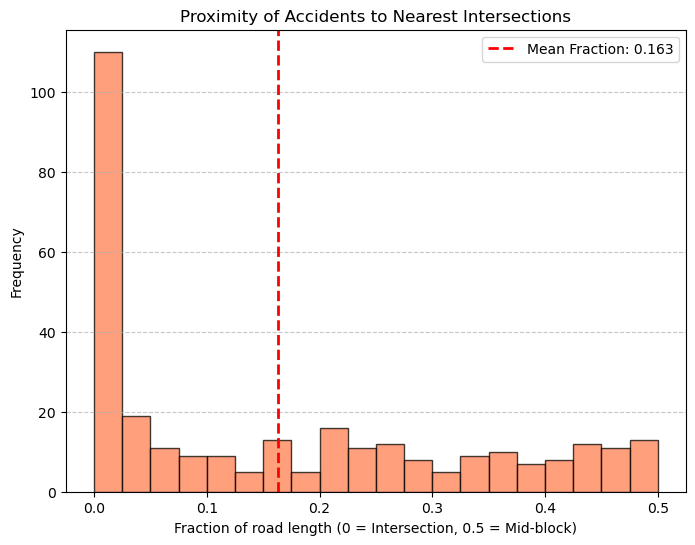

In [51]:
# Task B.2: Spaghetti Network Snapping
nodes, edges = ox.graph_to_gdfs(G_leeds_raw)
spaghetti_net = spaghetti.Network(in_data=edges)
spaghetti_net.snapobservations(final_accidents_df, 'accidents', attribute=True)

# Plot snapped points
# > TUNE: Added introductory text to avoid abrupt output
print("\n Visualizing snapped accident locations on the Leeds network ")
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color='lightgrey', linewidth=1, zorder=1)
snapped_coords = spaghetti_net.pointpatterns['accidents'].snapped_coordinates
sx = [coords[0] for coords in snapped_coords.values()]
sy = [coords[1] for coords in snapped_coords.values()]
ax.scatter(sx, sy, c='red', s=20, alpha=0.7, zorder=2, label='Snapped')
ax.set_title("Network-Snapped Traffic Accidents")
ax.legend()
plt.axis('off')
plt.show()

# Network Moran's I
print("\n Network Moran's I results ")
obs_to_arc = spaghetti_net.pointpatterns['accidents'].obs_to_arc
counts_dict = spaghetti_net.count_per_link(obs_to_arc, graph=False)
w_network = spaghetti_net.contiguityweights(graph=False, weightings=False)
arcs = list(w_network.neighbors.keys())
y = np.array([counts_dict.get(arc, 0) for arc in arcs])

np.random.seed(42) 
moran = esda.Moran(y, w_network, permutations=999)
print(f"Moran's I: {moran.I:.4f}, P-value: {moran.p_sim:.4f}")

# Network K-Function
# > TUNE: Added introductory text for K-Function plot
print("\n Task B.2: Network K-Function Plot ")
print("Calculating Network K-Function...")
kres = spaghetti_net.GlobalAutoK(spaghetti_net.pointpatterns['accidents'], nsteps=10, permutations=99)

plt.figure(figsize=(8, 6))
plt.plot(kres.xaxis, kres.observed, 'b-', linewidth=2, label='Observed K')
plt.plot(kres.xaxis, kres.upperenvelope, 'r--', label='Upper 95% CI')
plt.plot(kres.xaxis, kres.lowerenvelope, 'g--', label='Lower 95% CI')
plt.fill_between(kres.xaxis, kres.lowerenvelope, kres.upperenvelope, color='gray', alpha=0.2)
plt.title("Network K-Function of Accidents")
plt.xlabel("Distance along the network (meters)")
plt.ylabel("K-Function Value")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Task B.3: Intersection Proximity
# > TUNE: Added introductory text for Histogram plot
print("\n Task B.3: Proximity Histogram ")
fractions = []
dist_to_vertex = spaghetti_net.pointpatterns['accidents'].dist_to_vertex

for obs_id, dist_dict in dist_to_vertex.items():
    distances = list(dist_dict.values())
    if len(distances) == 2:
        arc_len = distances[0] + distances[1]
        if arc_len > 0:
            fractions.append(min(distances) / arc_len)

plt.figure(figsize=(8, 6))
plt.hist(fractions, bins=20, range=(0, 0.5), color='coral', edgecolor='black', alpha=0.75)
mean_frac = np.mean(fractions)
plt.axvline(mean_frac, color='red', linestyle='dashed', linewidth=2, label=f'Mean Fraction: {mean_frac:.3f}')
plt.title("Proximity of Accidents to Nearest Intersections")
plt.xlabel("Fraction of road length (0 = Intersection, 0.5 = Mid-block)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


 Visualizing Voronoi Zones for Marathons 


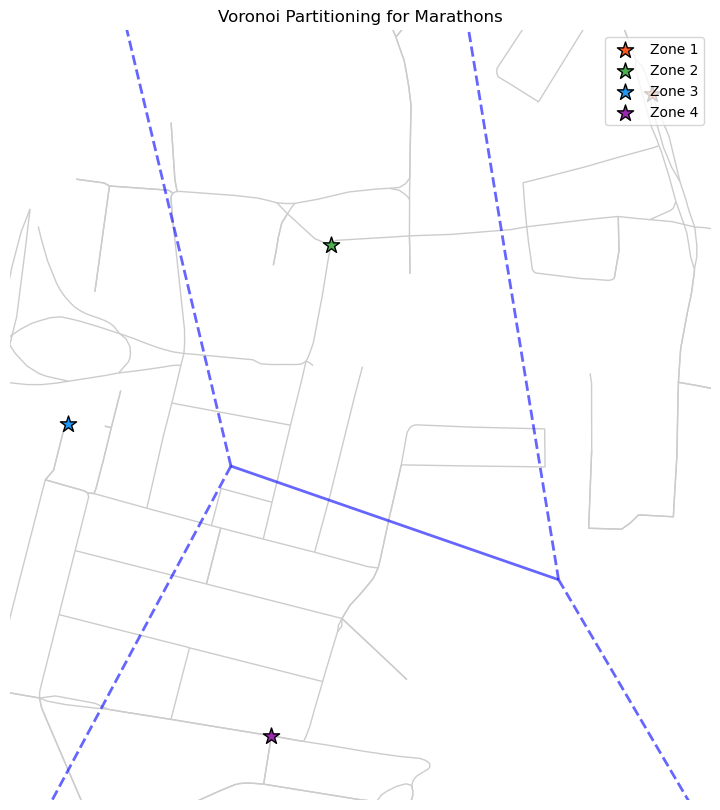


 Capacity Check (500m radius) 
Zone 1 total road length: 5.01 km
Zone 2 total road length: 1.82 km
Zone 3 total road length: 3.04 km
Zone 4 total road length: 2.69 km


In [52]:
# Task C.1 & C.2: Voronoi Partitioning
coords = np.array([[point.x, point.y] for point in nodes_df['geometry']])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(coords)
seed_points_lon_lat = kmeans.cluster_centers_
marathon_seeds = ox.nearest_nodes(G_leeds_raw, seed_points_lon_lat[:, 0], seed_points_lon_lat[:, 1])

print("\n Visualizing Voronoi Zones for Marathons ")
fig, ax = plt.subplots(figsize=(10, 10))
edges_gdf = ox.graph_to_gdfs(G_leeds_raw, nodes=False)
edges_gdf.plot(ax=ax, color='#cccccc', linewidth=1, zorder=1)

seed_xs = nodes_df.loc[marathon_seeds].geometry.x.values
seed_ys = nodes_df.loc[marathon_seeds].geometry.y.values
vor = Voronoi(np.column_stack((seed_xs, seed_ys)))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='blue', line_width=2, line_alpha=0.6, point_size=0)

colors = ['#FF5722', '#4CAF50', '#2196F3', '#9C27B0']
for i in range(4):
    # 微调：加上了 label=f'Zone {i+1}'
    ax.scatter(seed_xs[i], seed_ys[i], c=colors[i], s=150, edgecolor='black', marker='*', zorder=5, label=f'Zone {i+1}')

ax.set_title("Voronoi Partitioning for Marathons")
ax.legend(loc='upper right') # 微调：把图例显示在右上角
plt.axis('off')
plt.show()

# Task C.3 & C.4: Check road capacity for each zone
print("\n Capacity Check (500m radius) ")
cell_nodes = {seed: [] for seed in marathon_seeds}
for node in G_leeds_raw.nodes():
    shortest_paths = []
    for seed in marathon_seeds:
        try:
            n1 = G_leeds_raw.nodes[node]
            s1 = G_leeds_raw.nodes[seed]
            dist = ((n1['x'] - s1['x'])**2 + (n1['y'] - s1['y'])**2)**0.5
            shortest_paths.append((dist, seed))
        except:
            continue
    if shortest_paths:
        closest_seed = min(shortest_paths, key=lambda x: x[0])[1]
        cell_nodes[closest_seed].append(node)

for i, seed in enumerate(marathon_seeds):
    subgraph = G_leeds_raw.subgraph(cell_nodes[seed])
    total_length_meters = sum([data.get('length', 0) if not isinstance(data.get('length', 0), list) else sum(data.get('length', 0)) for u, v, data in subgraph.edges(data=True)])
    print(f"Zone {i+1} total road length: {(total_length_meters / 1000):.2f} km")

Calculating 42km route...
Path generated. Total length: 45.98 km


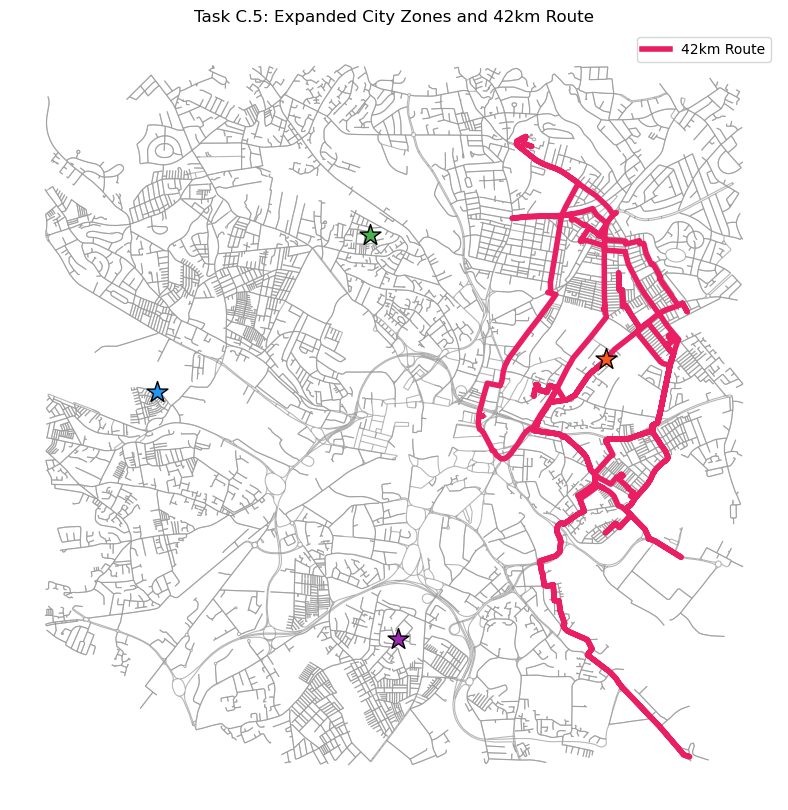

In [53]:
# Task C.5: Expand area and plan a 42km closed loop
radius_meters = 3500 
print(f"Downloading larger network (Radius: {radius_meters}m)...")
G_large = ox.graph_from_point(leeds_center, dist=radius_meters, network_type='drive')
G_large = G_large.subgraph(max(nx.strongly_connected_components(G_large), key=len)).copy()

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_large)
G_un = nx.Graph(G_large) 

# Re-calculate zones for the larger map
coords = np.array([[point.x, point.y] for point in nodes_gdf['geometry']])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(coords)
seed_points = kmeans.cluster_centers_
seed_nodes = ox.nearest_nodes(G_large, seed_points[:, 0], seed_points[:, 1])

cell_nodes = {seed: [] for seed in seed_nodes}
for node in G_un.nodes():
    n_data = G_un.nodes[node]
    dists = [((n_data['x'] - G_un.nodes[s]['x'])**2 + (n_data['y'] - G_un.nodes[s]['y'])**2, s) for s in seed_nodes]
    cell_nodes[min(dists)[1]].append(node)
    
# Generate route strictly in Zone 1
target_seed = seed_nodes[0]
subgraph_raw = G_un.subgraph(cell_nodes[target_seed])
largest_cc = max(nx.connected_components(subgraph_raw), key=len)
subgraph = subgraph_raw.subgraph(largest_cc).copy()

marathon_path = [target_seed]
current_length = 0
current_node = target_seed
nodes_list = list(subgraph.nodes())
random.seed(2026) 

print("Calculating 42km route...")
while current_length < 40000:
    next_target = random.choice(nodes_list)
    try:
        path_segment = nx.shortest_path(subgraph, current_node, next_target, weight='length')
        for i in range(len(path_segment)-1):
            d = subgraph.get_edge_data(path_segment[i], path_segment[i+1])
            l = d.get('length', 0) if not isinstance(d.get('length', 0), list) else d.get('length', 0)[0]
            current_length += l
        marathon_path.extend(path_segment[1:])
        current_node = next_target
    except nx.NetworkXNoPath:
        continue
        
try:
    # Return to start to close the loop
    return_segment = nx.shortest_path(subgraph, current_node, target_seed, weight='length')
    for i in range(len(return_segment)-1):
        d = subgraph.get_edge_data(return_segment[i], return_segment[i+1])
        l = d.get('length', 0) if not isinstance(d.get('length', 0), list) else d.get('length', 0)[0]
        current_length += l
    marathon_path.extend(return_segment[1:])
except nx.NetworkXNoPath:
    pass
    
print(f"Path generated. Total length: {(current_length/1000):.2f} km")

# Plot final route
fig, ax = plt.subplots(figsize=(10, 10)) 
edges_gdf.plot(ax=ax, color='#999999', linewidth=0.8, alpha=0.7, zorder=1)

path_x = [G_un.nodes[n]['x'] for n in marathon_path]
path_y = [G_un.nodes[n]['y'] for n in marathon_path]
ax.plot(path_x, path_y, c='#E91E63', linewidth=4, zorder=5, label='42km Route')

colors = ['#FF5722', '#4CAF50', '#2196F3', '#9C27B0']
for i, seed in enumerate(seed_nodes):
    ax.scatter(G_un.nodes[seed]['x'], G_un.nodes[seed]['y'], c=colors[i], s=250, marker='*', edgecolor='black', zorder=6)
    
ax.set_title("Task C.5: Expanded City Zones and 42km Route")
ax.legend()
plt.axis('off')
plt.show()